In [1]:
#impor cell
import numpy as np #data processing and plotting
import pandas as pd 
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression #model imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

In [2]:
#database locations
temp_csv='/Users/noahrogers/Desktop/AI_Research_Project/temp.csv'
energy_csv='/Users/noahrogers/Desktop/AI_Research_Project/renewable.csv'

# Temperature Analysis

In [3]:
#tempdata read/preprocess
tempdata = pd.read_csv(temp_csv, encoding='latin-1')#reading for scv encoded to handle sybols
tempdata=tempdata.dropna()#dropping rows containing missing values
tempdata=tempdata[tempdata['Element']=='Temperature change']# foucsed data to temperature change exluding stadard deviation data
tempdata=tempdata.drop(columns=['Area Code','Months Code','Element Code', 'Element','Unit'])#dropped redundant columns for identificaiton 
tempdata=tempdata.rename(columns={'Area':'Country'})#rename column to better represent data

In [4]:
#temperature change prepro
tempc =tempdata[tempdata['Months'].isin([ #filters data to exclude rows of combined months data
'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])]
#print(tempc['Country'].unique())#this was to get a list of unique areas(renamed countries) to exclude grouped data like continents, commented out to make readable
tempc=tempc.melt(id_vars=['Country','Months'],var_name='Year', value_name='Temp Change')#.melt changes the arangment of the data leving the first 2 and single column values 
tempc['Year'] = tempc['Year'].str[1:].astype('str')#removes the y infront of year from the dataset
remove=['World', 'Africa', 'Eastern Africa', 'Middle Africa', 'Northern Africa', 'Southern Africa', 'Western Africa', 
'Americas', 'Northern America', 'Central America', 'Caribbean', 'South America', 'Asia', 'Central Asia', 
'Eastern Asia', 'Southern Asia', 'South-Eastern Asia', 'Western Asia', 'Europe', 'Eastern Europe', 'Northern Europe', 
'Southern Europe', 'Western Europe', 'Oceania','Australia and New Zealand', 'Melanesia', 'Micronesia', 
'Polynesia', 'European Union', 'Least Developed Countries', 'Land Locked Developing Countries', 'Small Island Developing States',
'Low Income Food Deficit Countries', 'Net Food Importing Developing Countries', 'Annex I countries','Non-Annex I countries', 'OECD']
tempc=tempc[~tempc['Country'].isin(remove)]#variable to remove the unwanted regions in the set, narrowing to only unique countries
#tempc.head()# check for proper processing


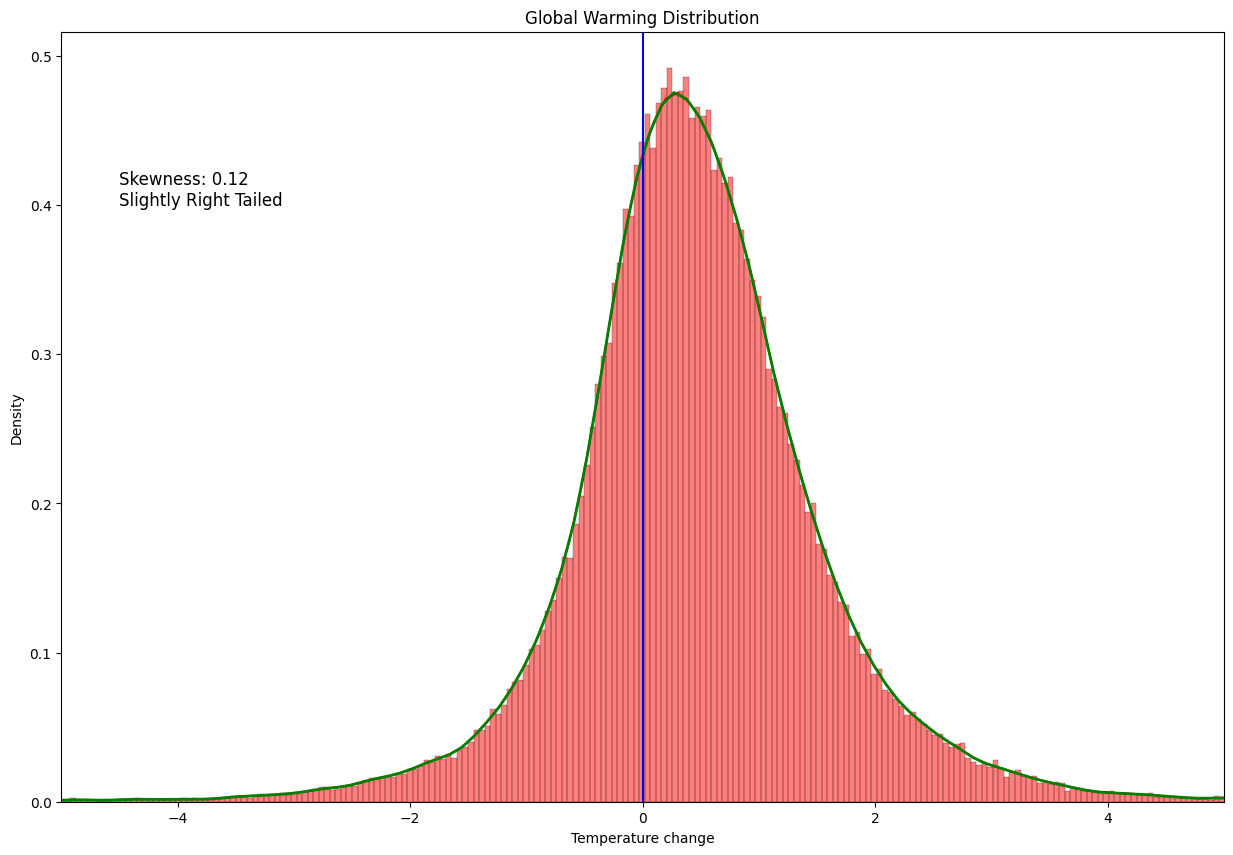

In [5]:
#plt for probability density functions 
plt.figure(figsize=(15,10))#created uniform plt size

sns.histplot(#created a histplot for the density of the data
    tempc['Temp Change'], #data input
    kde=True, #kernal density curve line call
    stat='density',#assinges this histogram to represent the PDF 
    color='red')
sns.kdeplot(#Created a seperate plot to customize the kde curve
    tempc['Temp Change'], #data input
    color='green' ,
    lw=2)#line width
plt.axvline(x=0.0, color='b', linestyle='-')#refrence line down the middle

skewness= stats.skew(tempc['Temp Change'])#caclulates skewness based on data
plt.text(-4.5,0.4, f"Skewness: {skewness:.2f}\n{'Slightly Right Tailed'}",fontsize=12, color='black')#adds text over the plot to report skewness

plt.xlabel('Temperature change')#labels
plt.title('Global Warming Distribution')
plt.xlim(-5,5)#limited range
plt.show()


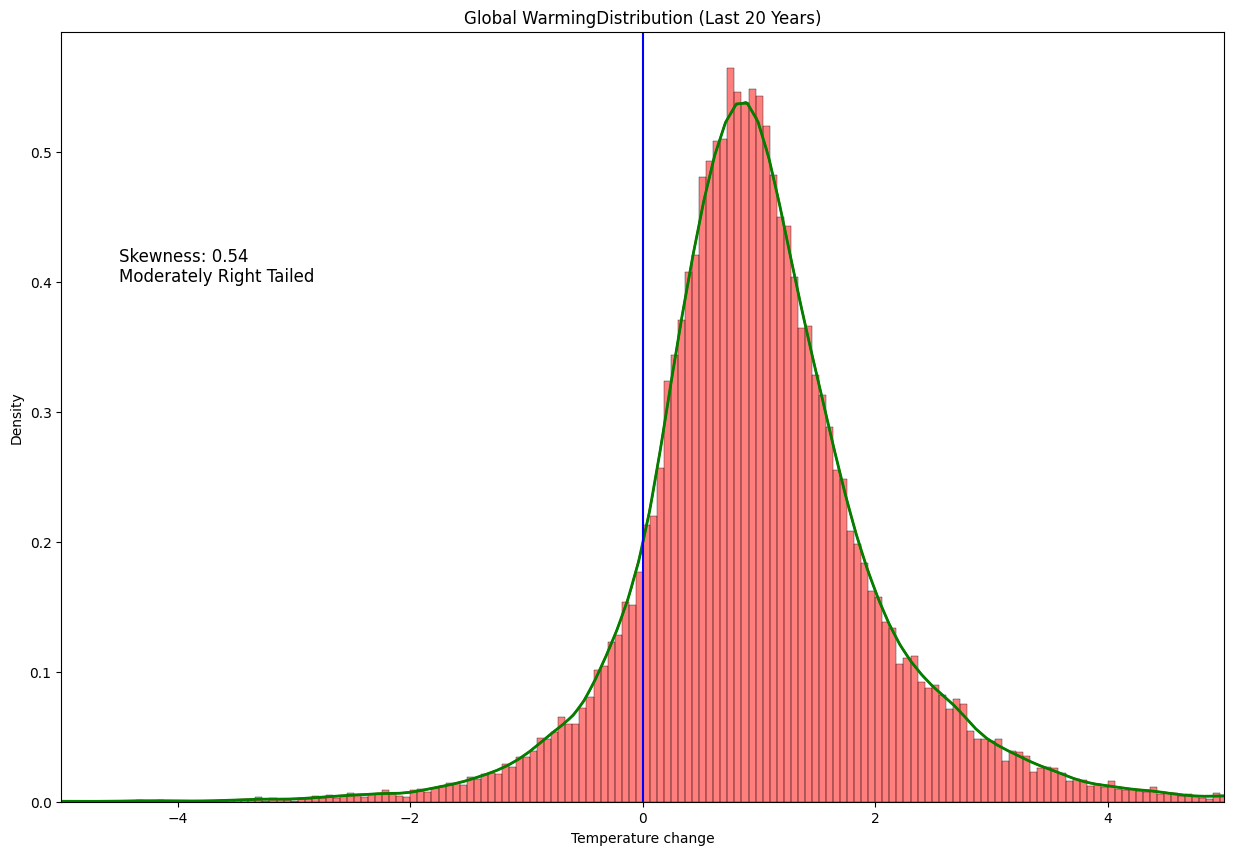

In [6]:
recentc= tempc.copy()#copied the df for another plt on the last 20 years in the set
recenty=recentc[recentc['Year'].astype(int) >= recentc['Year'].astype(int).max() - 20]

plt.figure(figsize=(15,10))#created uniform plt size
sns.histplot(#created a histplot for the density of the data
    recenty['Temp Change'], #data input
    kde=True, #kernal density curve line call
    stat='density',#assinges this histogram to represent the PDF 
    color='red')
sns.kdeplot(#Created a seperate plot to customize the kde curve
    recenty['Temp Change'], #data input
    color='green',
    lw=2)#line width
plt.axvline(x=0.0, color='b', linestyle='-')#refrence line down the middle
# Add skewness information and interpretation as text on the plot
skewness= stats.skew(recenty['Temp Change'])#caclulates skewness based on data
plt.text(-4.5,0.4, f"Skewness: {skewness:.2f}\n{'Moderately Right Tailed '}",fontsize=12, color='black')#adds text over the plot to report skewness

plt.xlabel('Temperature change')#labels
plt.title('Global WarmingDistribution (Last 20 Years)')
plt.xlim(-5,5)
plt.show()

In [7]:
#cell for calculations for next graph
agvt=tempc.groupby('Year',  as_index=False)['Temp Change'].mean( )#avg temp of the whole world
avgc=tempc.groupby(['Country', 'Year'],as_index=False)['Temp Change'].mean()#means by country
#print(agvt.head())#checks, edited out
#print(avgc.head())#checks, edited out

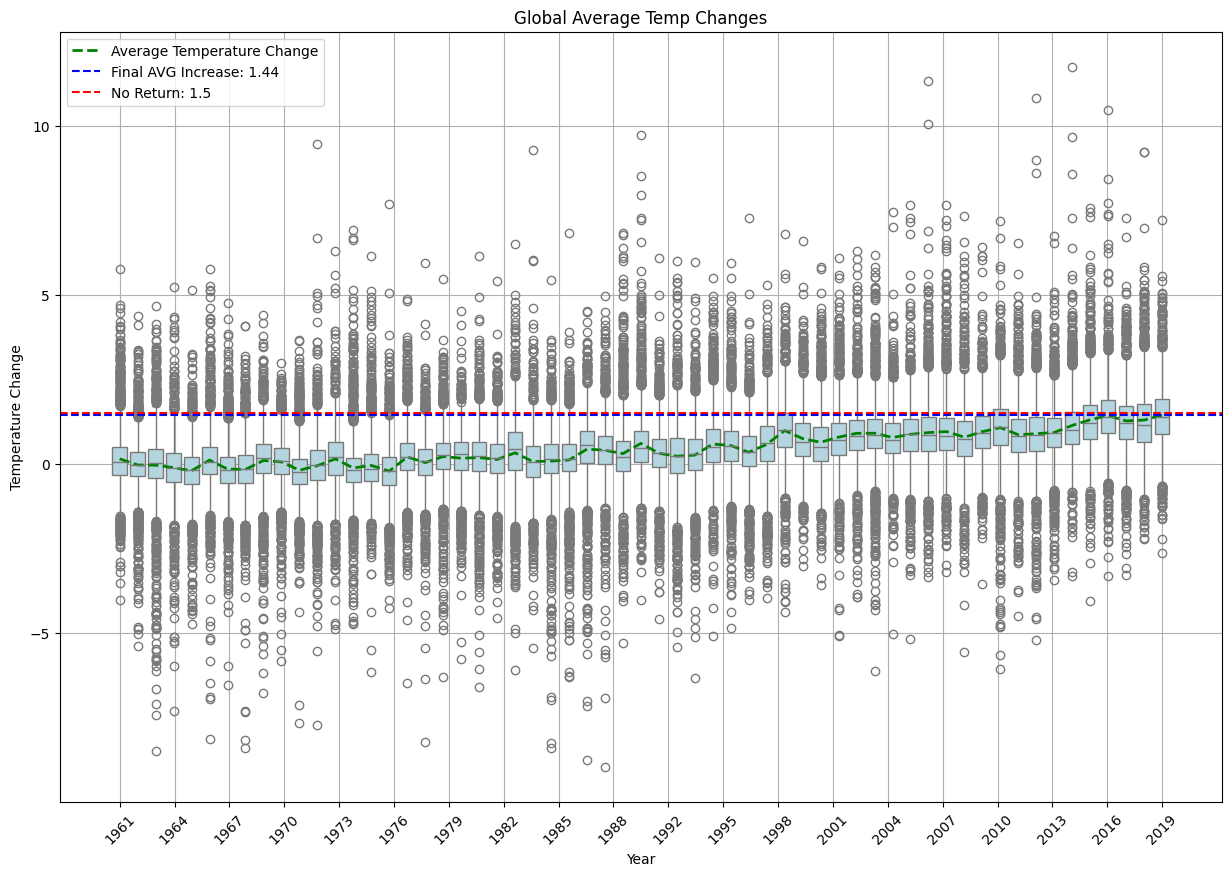

In [8]:
#Plot for better interpretation of PDF
plt.figure(figsize=(15,10))#created uniform plt size

sns.boxplot(x='Year', y='Temp Change',  data=tempc, color='lightblue')#boxplot for each year

plt.plot(agvt.Year, agvt['Temp Change'],'g--', label='Average Temperature Change', linewidth=2)#dashed line for avg by year

lastavg=agvt['Temp Change'].iloc[-1]#assigned variable for the last avg calculated
plt.axhline(y=lastavg, color='blue', linestyle='--', label=f'Final AVG Increase: {lastavg:.2f}')#plotted the last value to show how close it is to the 1.5C line
plt.axhline(y=1.5, color='red', linestyle='--', label='No Return: 1.5')#plotted line for the desibed 1.5c increase

plt.xlabel('Year')#labels
plt.ylabel('Temperature Change')
plt.xticks(np.linspace(0, 58, 20), rotation=45)#spacing fix to stop overcrowded plot  (numpy linespace 20 values 0-58) rotate years 45 for readability
plt.title('Global Average Temp Changes')
plt.grid(True)#grid background
plt.legend()#legend call to show plotted label values
plt.show()

# Regression Predictions

In [9]:
#preprocessing for regression
monthid={#dictionary to replace strings with single value
'January':'1','February':'2','March':'3','April':'4','May':'5','June':'6',
'July':'7','August':'8','September':'9','October':'10','November':'11','December':'12'}
tempc=tempc.replace(monthid)#replaces keys with values
#tempc.head()#check edited out
y=tempc['Temp Change']#assigned variables
x=tempc.drop(columns=['Temp Change','Country','Months'])# dropped columns instead of assigned column due to value error
#x.head()#check edited out

In [10]:
xtr, xte, ytr, yte = train_test_split(x, y, train_size=0.25,random_state=42)#traintestsplit on x,y into xtrain and test and ytrain and test(.25 size for training)random state for reproduction
lr =LinearRegression()#variable for model
lr.fit(xtr, ytr)#fit training data
lrpred=lr.predict(xte)#prediction on test data variable 

mae=mean_absolute_error(yte,lrpred)#accuracy checks on test data 
mse=mean_squared_error(yte,lrpred)
rmse=np.sqrt(mse)
r2=r2_score(yte, lrpred)

print("Mean Absolute Error:" , mae)#print statments for error
print("Mean Squared Error:",mse)
print("Root Mean Square Error:", rmse)
print("R-squared Score:", r2)

Mean Absolute Error: 0.6932094878015344
Mean Squared Error: 1.0191320418509635
Root Mean Square Error: 1.0095206990700902
R-squared Score: 0.16139766299865754


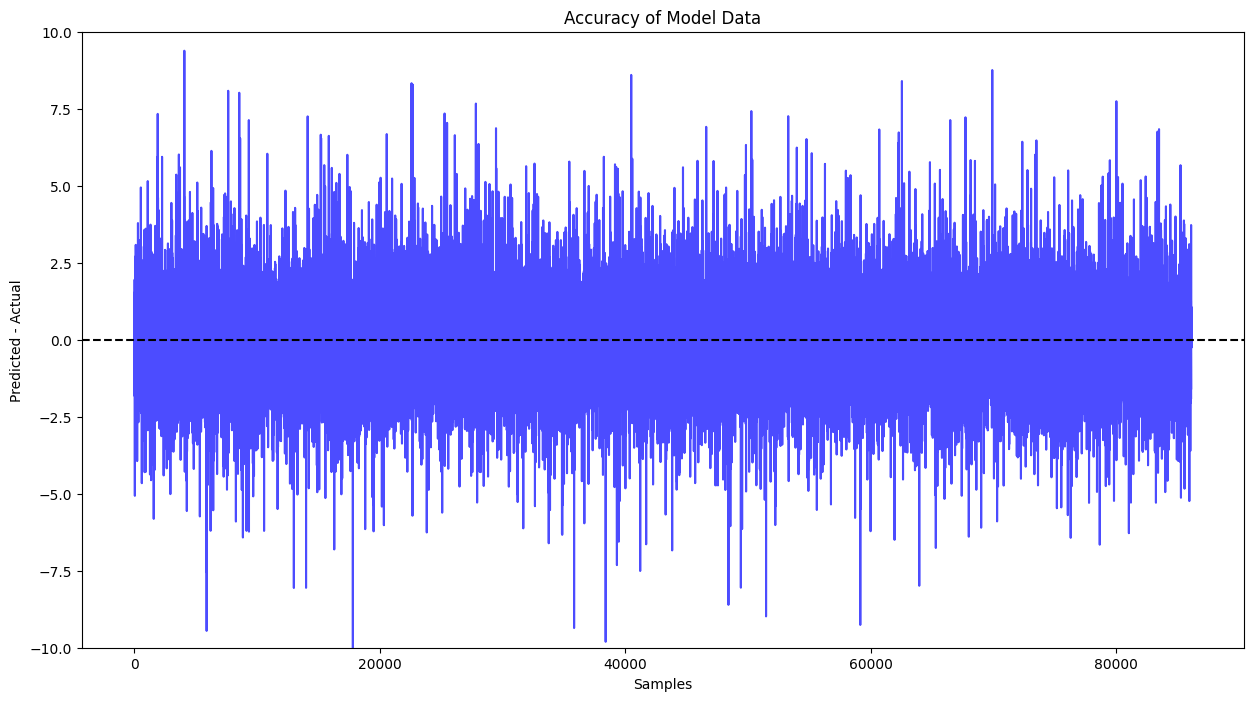

In [11]:
#plt for visualization of prediction accuracy
plt.figure(figsize=(15,8))#created uniform plt size

plt.plot(np.arange(len(yte)), lrpred - yte, color='blue',alpha=.7)#plots an aragment of the difference between the predicted values and the test data for each value
plt.axhline(y=0.0, color='k', linestyle='--')#refrence line at 0
plt.ylabel('Predicted - Actual')#labels
plt.xlabel('Samples')
plt.title('Accuracy of Model Data')

plt.ylim(-10,10)#set range
plt.show()

In [12]:
x =agvt['Year'].values.reshape(-1, 1)#reshaped years 
y =agvt['Temp Change'].values#set y 

poly= PolynomialFeatures(degree=2)#variable for model
polyx=poly.fit_transform(x)#.fit transform applies the squaring on the independent variable

lr.fit(polyx, y)#fit linear regression on the poly transformed data

future=np.arange(2019, 2051).reshape(-1, 1)#variable arraning the future years in the same format
futurep=poly.transform(future)#fits to future year values
prpred=lr.predict(futurep)#prediction for future temp change

[2022]


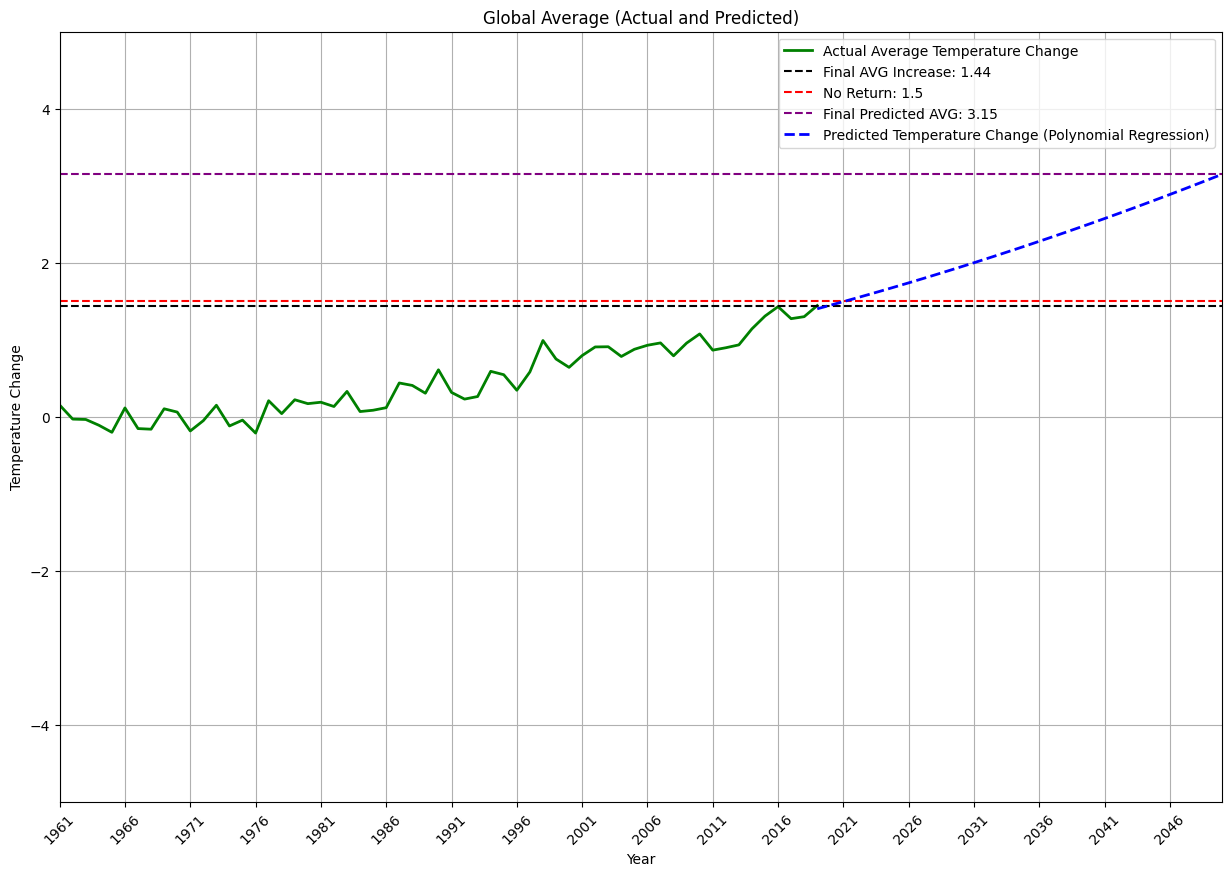

In [13]:
#plot for predictions overlaped with previous avgs
agvt['Year']=agvt['Year'].astype(int)#makes sure that years are ints

plt.figure(figsize=(15,10))#created uniform plt size

plt.plot(agvt['Year'], agvt['Temp Change'], 'g-', label='Actual Average Temperature Change', linewidth=2)# plot from the previous avgs line
plt.axhline(y=lastavg, color='black', linestyle='--', label=f'Final AVG Increase: {lastavg:.2f}')#last avg line from previous graph
plt.axhline(y=1.5, color='red', linestyle='--', label='No Return: 1.5')#no return line from previous graph

finalpredavg = prpred[-1]#singeled out the final avg from predictions
plt.axhline(y=finalpredavg, color='purple', linestyle='--', label=f'Final Predicted AVG: {finalpredavg:.2f}')#plotting last prediction

plt.plot(future, prpred, 'b--',label='Predicted Temperature Change (Polynomial Regression)', linewidth=2)#plot for the future line

allyears = np.concatenate([agvt['Year'].values, future.flatten()])#concatenate previous and future years

crityear =future[np.argmax(prpred > 1.5)]#variable to find out the year we exceeded 1.5C
print (crityear)#print for refrence
plt.xticks(np.arange(allyears.min(), allyears.max() + 1, 5), rotation=45)#spacing fix setting year every 5 years rotaing for readability 

plt.xlabel('Year')#labels
plt.ylabel('Temperature Change')
plt.title('Global Average (Actual and Predicted)')

plt.xlim(allyears.min(), allyears.max())#ajust range to fit all years 
plt.ylim(-5, 5)
plt.grid(True)
plt.legend()
plt.show()

# Energy Analysis

In [14]:
df=pd.read_csv(energy_csv)#read the energy csv
#dfc['Country'].unique()#check to see the countries
dfc =df.groupby('Country').agg({'Investments (USD)':'sum'}).reset_index()#grouped by country, aggregated sums for investments, reset index to retain default layout
dfc['Investments (USD) in Billions'] = dfc['Investments (USD)'] / 1e9#converted money for readability 
dfc =dfc.sort_values(by='Investments (USD) in Billions',ascending=False)# sorted investments from high to low 

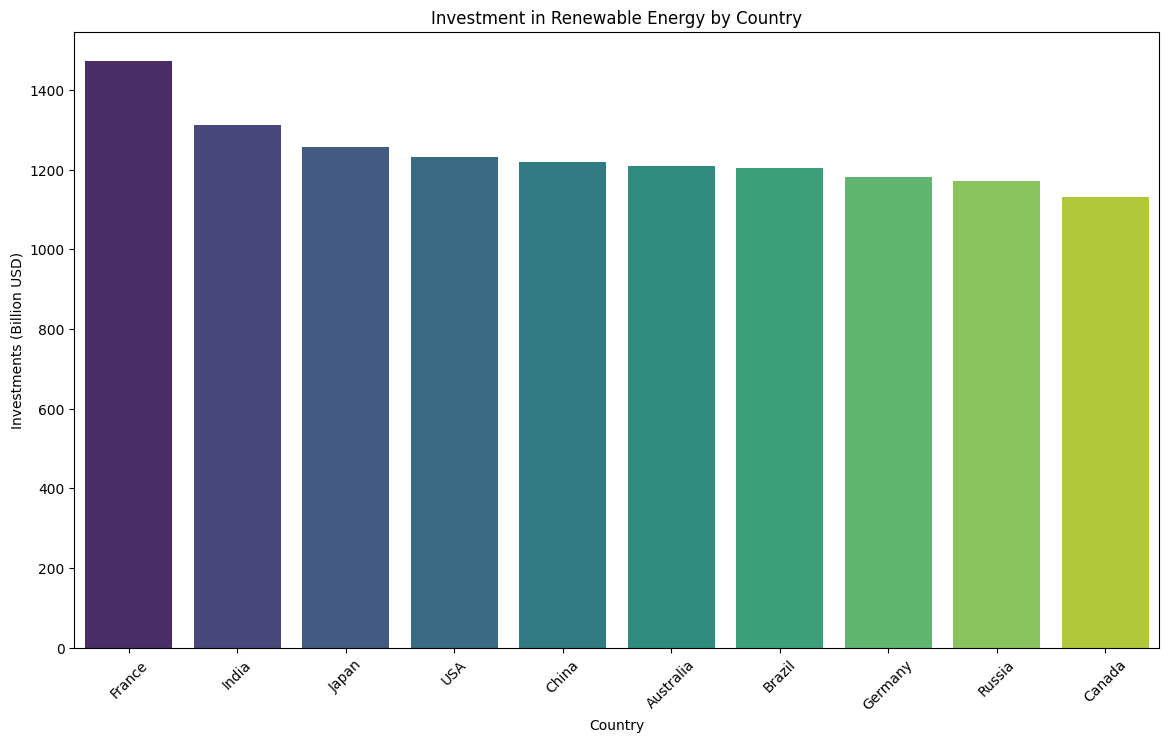

In [15]:
#plot of spending on renewables by country
plt.figure(figsize=(14,8))#created uniform plt size

sns.barplot(data=dfc, x='Country', y='Investments (USD) in Billions', hue='Country',palette='viridis')#barplot for spending  with color based on rank

plt.title('Investment in Renewable Energy by Country')#labels
plt.ylabel('Investments (Billion USD)' )

plt.xticks(rotation=45)#readabilty of countries
plt.show()

/var/folders/94/_yvw94zx4sz4vqjh1bp9nrdw0000gn/T/ipykernel_60714/2644156152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfusa['Green Energy Percentage']=(dfusa['Production (GWh)']/dfusa['Energy Consumption'])*100#variable to calculate the green energy coverage percentage


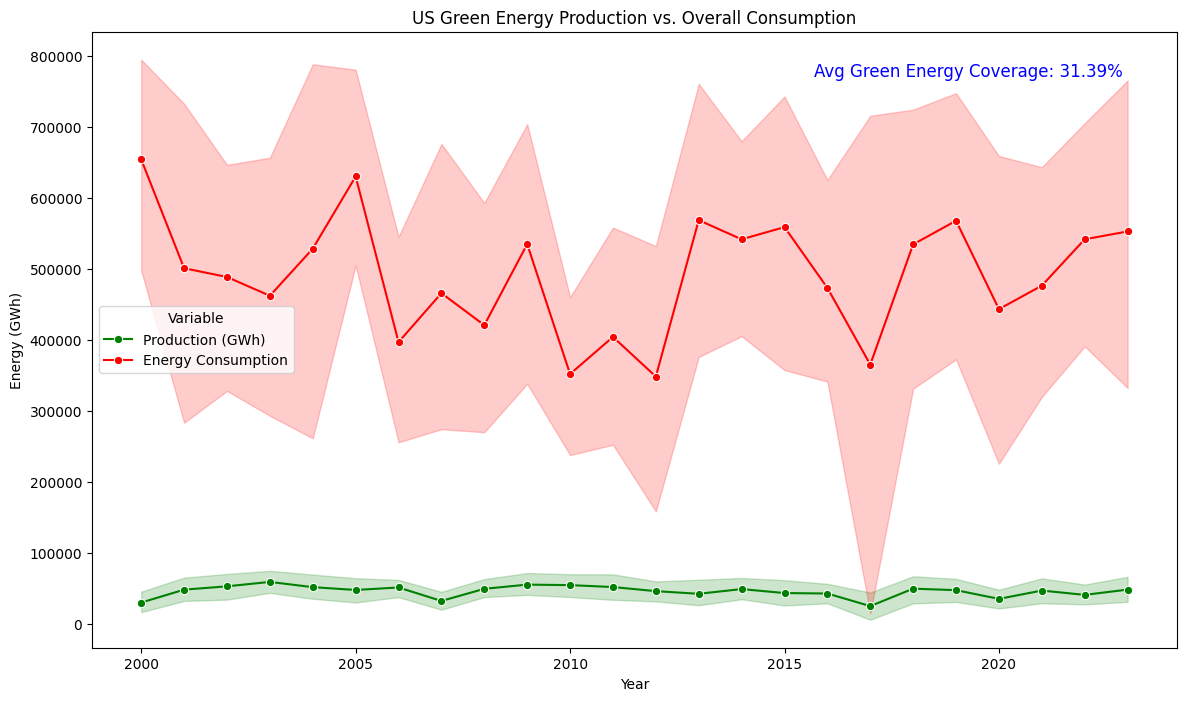

In [16]:
#energy analysis for the us
dfusa= df.loc[df.Country == 'USA']#filter data to usa
dfusa['Green Energy Percentage']=(dfusa['Production (GWh)']/dfusa['Energy Consumption'])*100#variable to calculate the green energy coverage percentage
dfmelt = pd.melt(dfusa, id_vars='Year', value_vars=['Production (GWh)', 'Energy Consumption'],var_name='Variable', value_name='Value') #.melt again to fix the columns of data

plt.figure(figsize=(14,8))#created uniform plt size
sns.lineplot(data=dfmelt,x='Year',y='Value',hue='Variable', marker='o', palette={'Production (GWh)': 'green', 'Energy Consumption': 'red'})#line plot for both overall consumption and green energy producition

plt.xlabel('Year')#labels
plt.ylabel('Energy (GWh)')
plt.title('US Green Energy Production vs. Overall Consumption')
plt.legend(title='Variable')

avgpercent = dfusa['Green Energy Percentage'].mean()#variable to calculate the mean of energy percentage
plt.text(x=0.95, y=0.95, s=f'Avg Green Energy Coverage: {avgpercent:.2f}%',ha='right', va='top', transform=plt.gca().transAxes, fontsize=12, color='blue')#plot text for avg coverage(transform fix for pixel placment)

plt.show()

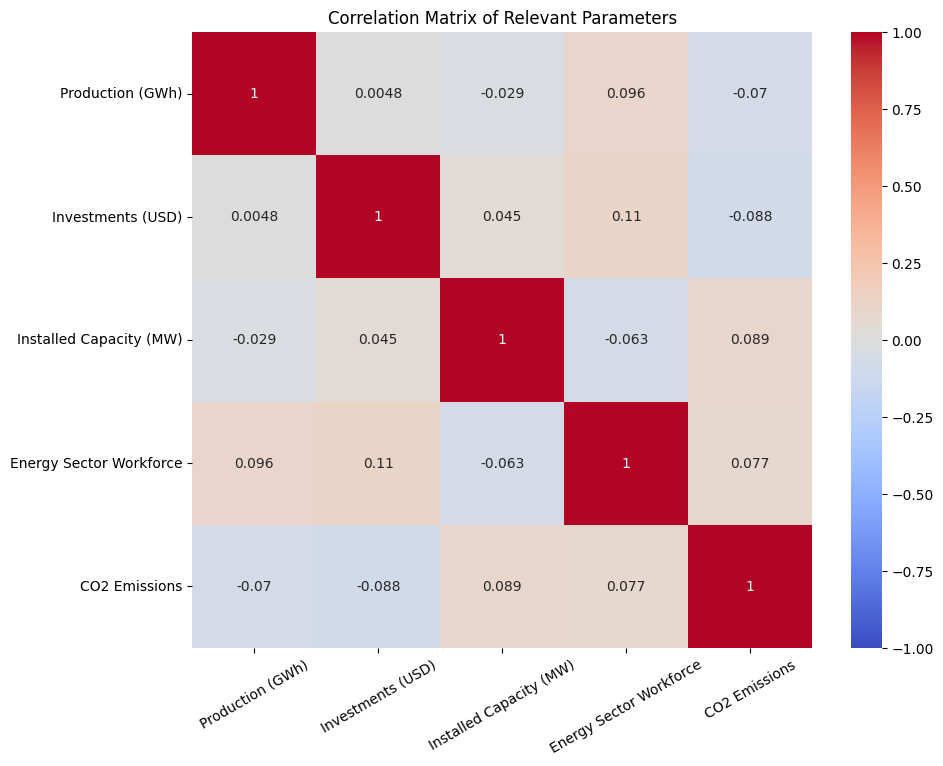

In [17]:
#Correlation Matrix
#seperated relevant features
dfusa=dfusa.loc[:, ['Production (GWh)', 'Investments (USD)', 'Installed Capacity (MW)', 'Energy Sector Workforce', 'CO2 Emissions']]
#dfusa.head()#check edited out

dfusa['Investments (USD)'] = np.log1p(dfusa['Investments (USD)'])#logerithmic normilization for money values (log1p is log(1 + x) to handle 0)

scale=StandardScaler()#variable for scalar
dfscaled=pd.DataFrame(scale.fit_transform(dfusa), columns=dfusa.columns)#scaling applied to all columns 

corr= dfscaled.corr()#call for corelations to be generated
#print(corr)#check edited out

plt.figure(figsize=(10, 8))#created uniform plt size
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)#heatmapping the matrix for visualization
plt.xticks(rotation=30)

plt.title('Correlation Matrix of Relevant Parameters' )#labels
plt.show()